In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc, f1_score, matthews_corrcoef, log_loss
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

import uproot
from iminuit import Minuit

import lightgbm as lgb

In [2]:
# true_data = pd.read_parquet('channel1_some_more_data.parquet')
# print(f'shape true data: {true_data.shape}')
true_data_22 = pd.read_parquet('/groups/hep/kinch/data/Data/data22_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp22_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 22: {true_data_22.shape}')
true_data_23 = pd.read_parquet('/groups/hep/kinch/data/Data/data23_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp23_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 23: {true_data_23.shape}')
MC_data = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/Data_BalZ_ttbar_zee.parquet')
print(f'shape MC data: {MC_data.shape}')

true_data = pd.concat([true_data_22, true_data_23])
print(f'shape data: {true_data.shape}')

shape data 22: (32936, 39)
shape data 23: (45757, 39)
shape MC data: (8792502, 40)
shape data: (78693, 39)


In [3]:
iso_param_list = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'm_lx_neflowisol20']

iso_1_param_list = ['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
                    'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000', 'l1_ptvarcone30_pt500',
                    'l1_topoetcone20', 'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20']

iso_2_param_list = ['l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
                    'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000', 'l2_ptvarcone30_pt500',
                    'l2_topoetcone20', 'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20']

small_iso_param_list1 = iso_1_param_list[-4:]
small_iso_param_list2 = iso_2_param_list[-4:]

pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 
                     'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0', 'EventInfo.actualIntPerXing'
                     , 'EventInfo.averageIntPerXing', 'EventInfo.mu']

others = ['EventInfo.eventNumber', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 'll_m', 'llg_m']

others_MC = ['EventInfo.eventNumber', 'truth_from_Z', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 'll_m', 'l1_truthType', 'l2_truthType']

param_list = iso_1_param_list + iso_2_param_list + pred_z_param_list[2:] + others

true_data = true_data[param_list]

MC_param_list = iso_1_param_list + iso_2_param_list + pred_z_param_list[2:] + others_MC


isdata_bool = np.ones(true_data.shape[0], dtype=bool)
true_data['isData'] = isdata_bool
isdata_bool = np.zeros(MC_data.shape[0], dtype=bool)
MC_data['isData'] = isdata_bool



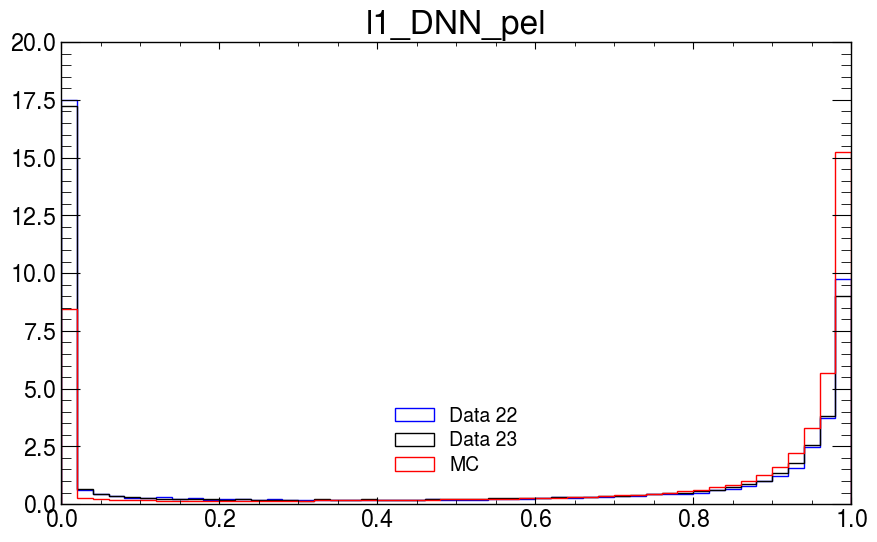

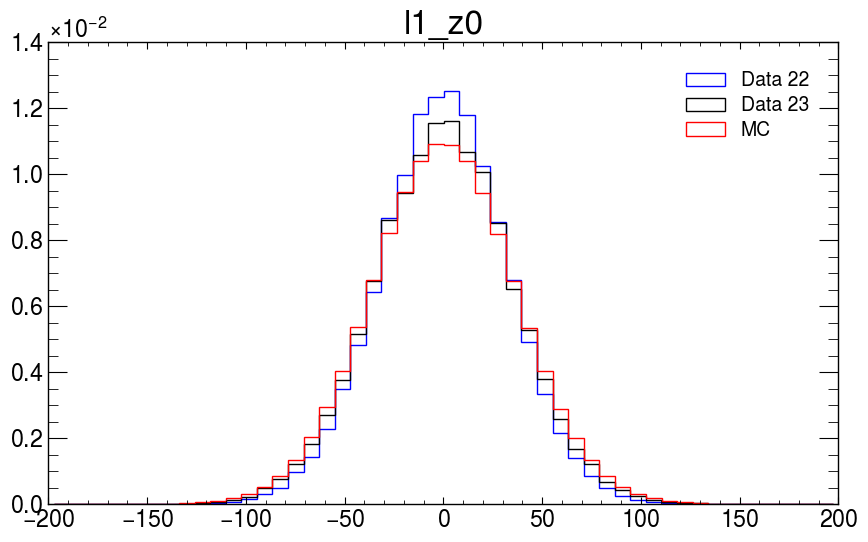

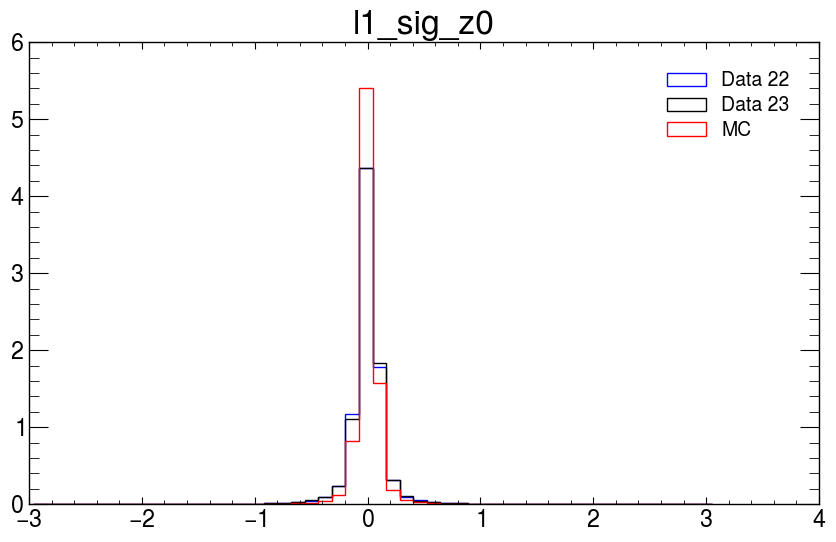

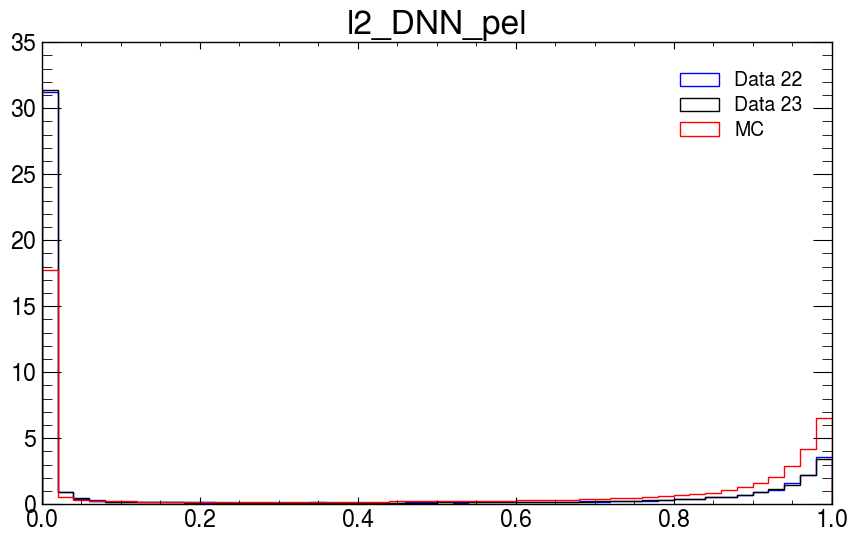

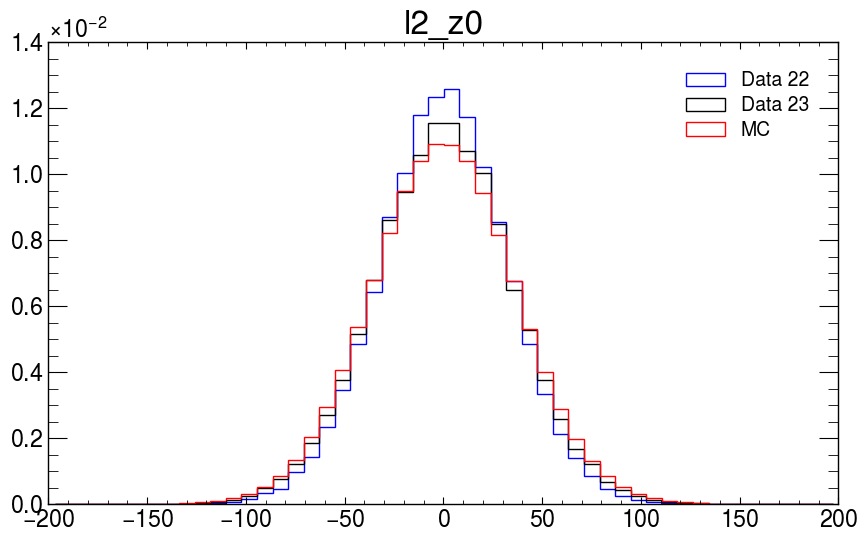

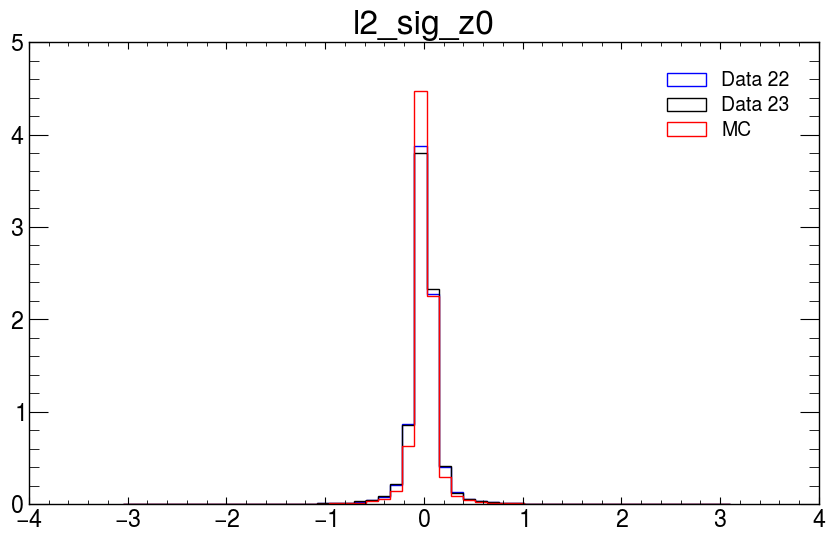

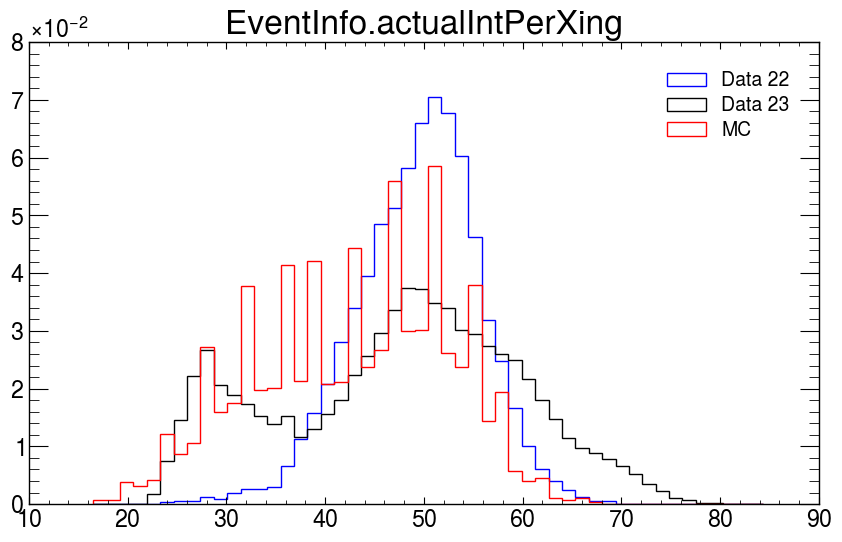

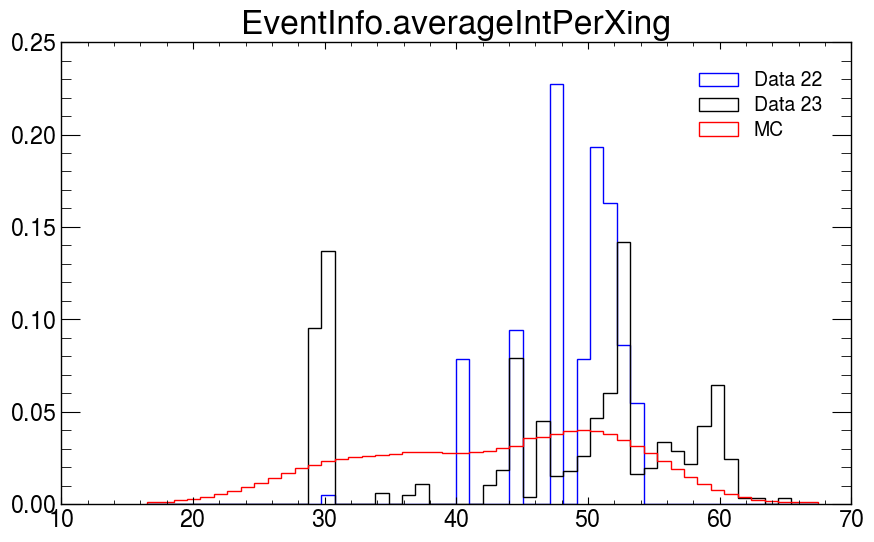

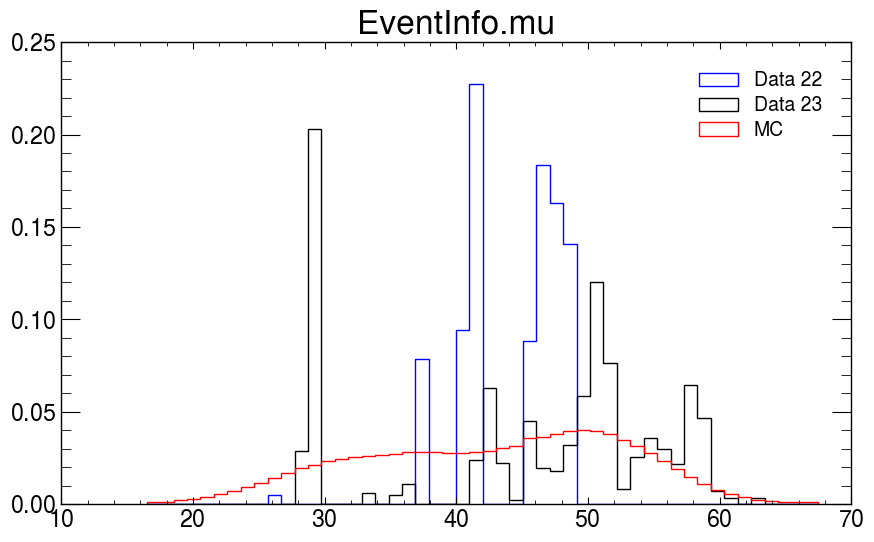

In [4]:
for i in range(len(pred_z_param_list[2:])):
    min_val = np.min([np.min(true_data_22[pred_z_param_list[i+2]]), np.min(true_data_23[pred_z_param_list[i+2]]), np.min(MC_data[pred_z_param_list[i+2]])])
    max_val = np.max([np.max(true_data_22[pred_z_param_list[i+2]]), np.max(true_data_23[pred_z_param_list[i+2]]), np.max(MC_data[pred_z_param_list[i+2]])])
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(true_data_22[pred_z_param_list[i+2]], bins=50, range=(min_val,max_val), histtype='step', label='Data 22', color='blue', density=True)
    ax.hist(true_data_23[pred_z_param_list[i+2]], bins=50, range=(min_val,max_val), histtype='step', label='Data 23', color='black', density=True)
    ax.hist(MC_data[pred_z_param_list[i+2]], bins=50, range=(min_val,max_val), histtype='step', label='MC', color='red', density=True)
    ax.set_title(pred_z_param_list[i+2])
    ax.legend()

In [5]:
true_data_22 = None
true_data_23 = None

delta_z0 = np.zeros(true_data.shape[0])
delta_sig_z0 = np.zeros(true_data.shape[0])

delta_z0 = np.abs(true_data['l1_z0'] - true_data['l2_z0'])
delta_sig_z0 = np.sqrt(true_data['l1_sig_z0']**2 + true_data['l2_sig_z0']**2)

delta_z0_norm = delta_z0/delta_sig_z0

true_data['DZ0'] = delta_z0_norm

delta_z0_MC = np.zeros(MC_data.shape[0])
delta_sig_z0_MC = np.zeros(MC_data.shape[0])

delta_z0_MC = np.abs(MC_data['l1_z0'] - MC_data['l2_z0'])
delta_sig_z0_MC = np.sqrt(MC_data['l1_sig_z0']**2 + MC_data['l2_sig_z0']**2)

delta_z0_norm_MC = delta_z0_MC/delta_sig_z0_MC

MC_data['DZ0'] = delta_z0_norm_MC

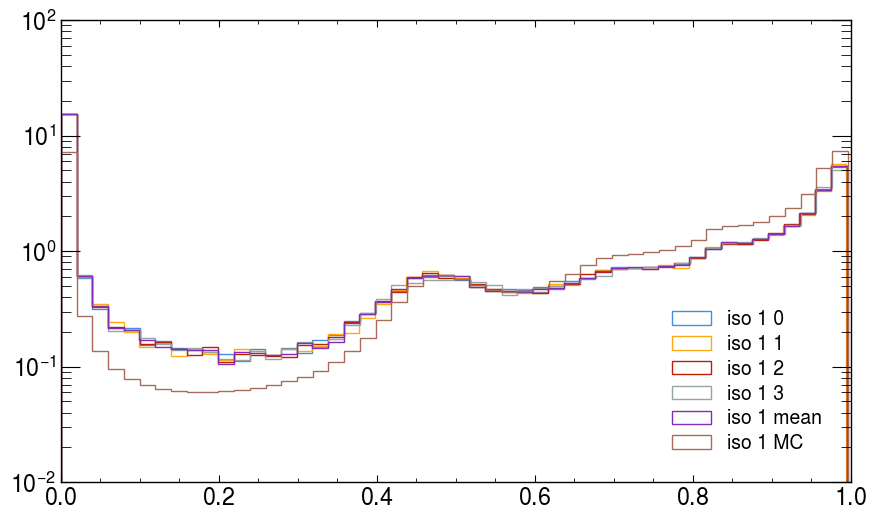

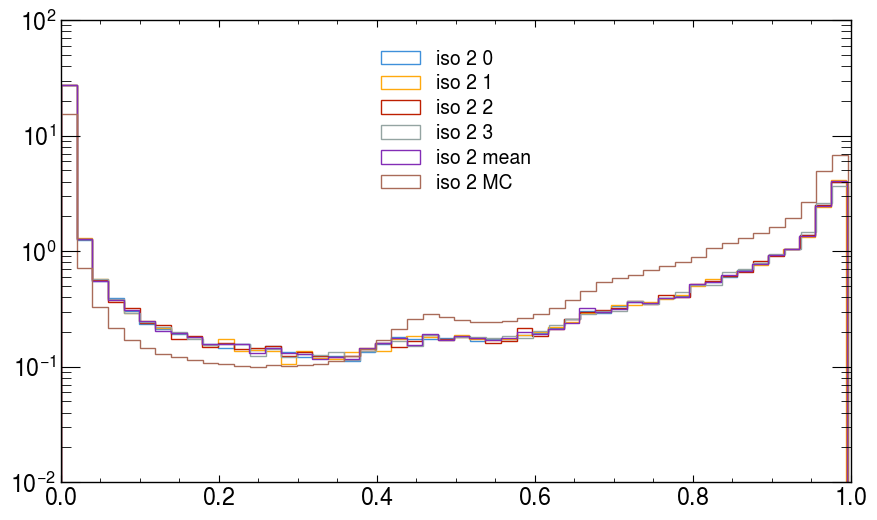

In [6]:
iso1 = np.zeros((true_data.shape[0],4))
iso2 = np.zeros((true_data.shape[0],4))

iso1_MC = np.zeros(MC_data.shape[0])
iso2_MC = np.zeros(MC_data.shape[0])

for i in range(4):
    with open(f'small_param_iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)

    X_test_1 = true_data[small_iso_param_list1]
    X_test_2 = true_data[small_iso_param_list2]
    iso1[:,i] = tuner.predict_proba(X_test_1)
    iso2[:,i] = tuner.predict_proba(X_test_2)

    mask_MC = MC_data['EventInfo.eventNumber'] % 4 == i
    X_test_1_MC = MC_data[mask_MC][small_iso_param_list1]
    X_test_2_MC = MC_data[mask_MC][small_iso_param_list2]
    iso1_MC[mask_MC] = tuner.predict_proba(X_test_1_MC)
    iso2_MC[mask_MC] = tuner.predict_proba(X_test_2_MC)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(iso1[:,0], bins=50, histtype='step', label='iso 1 0', density=True)
ax.hist(iso1[:,1], bins=50, histtype='step', label='iso 1 1', density=True)
ax.hist(iso1[:,2], bins=50, histtype='step', label='iso 1 2', density=True)
ax.hist(iso1[:,3], bins=50, histtype='step', label='iso 1 3', density=True)
ax.hist(np.mean(iso1, axis=1), bins=50, histtype='step', label='iso 1 mean', density=True)
ax.hist(iso1_MC, bins=50, histtype='step', label='iso 1 MC', density=True)
ax.set_yscale('log')
ax.legend()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(iso2[:,0], bins=50, histtype='step', label='iso 2 0', density=True)
ax.hist(iso2[:,1], bins=50, histtype='step', label='iso 2 1', density=True)
ax.hist(iso2[:,2], bins=50, histtype='step', label='iso 2 2', density=True)
ax.hist(iso2[:,3], bins=50, histtype='step', label='iso 2 3', density=True)
ax.hist(np.mean(iso2, axis=1), bins=50, histtype='step', label='iso 2 mean', density=True)
ax.hist(iso2_MC, bins=50, histtype='step', label='iso 2 MC', density=True)
ax.set_yscale('log')
ax.legend()

iso1 = np.mean(iso1, axis=1)
iso2 = np.mean(iso2, axis=1)


true_data['l1_iso_score'] = iso1
true_data['l2_iso_score'] = iso2

MC_data['l1_iso_score'] = iso1_MC
MC_data['l2_iso_score'] = iso2_MC

iso1 = None
iso2 = None
iso1_MC = None
iso2_MC = None

(exptext: Custom Text(0.05, 0.95, 'ATLAS'),
 expsuffix: Custom Text(0.05, 0.955, 'work in progress'),
 supptext: Custom Text(0.05, 0.95, ''),
 expsuffix: Custom Text(0.05, 0.95, '$\\sqrt{s}=13.6$ TeV'))

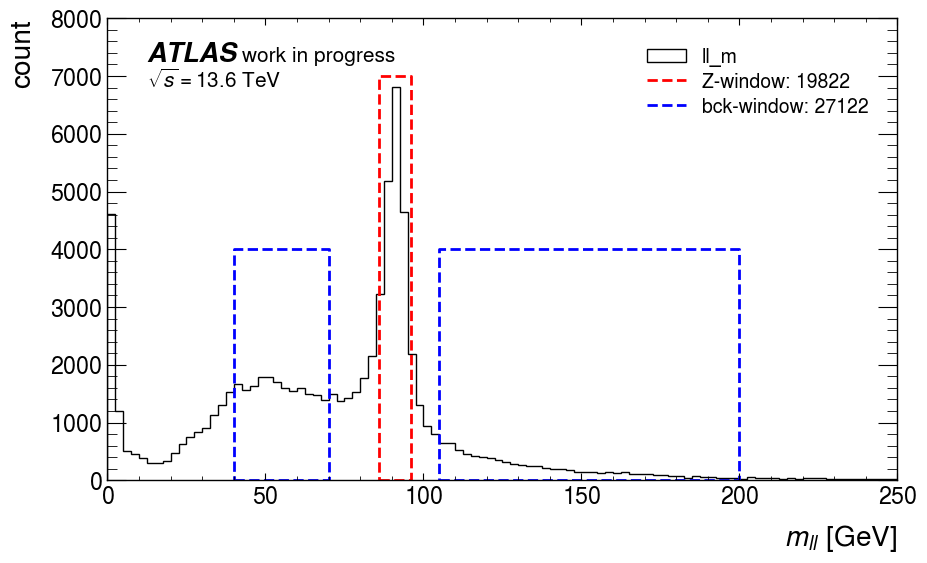

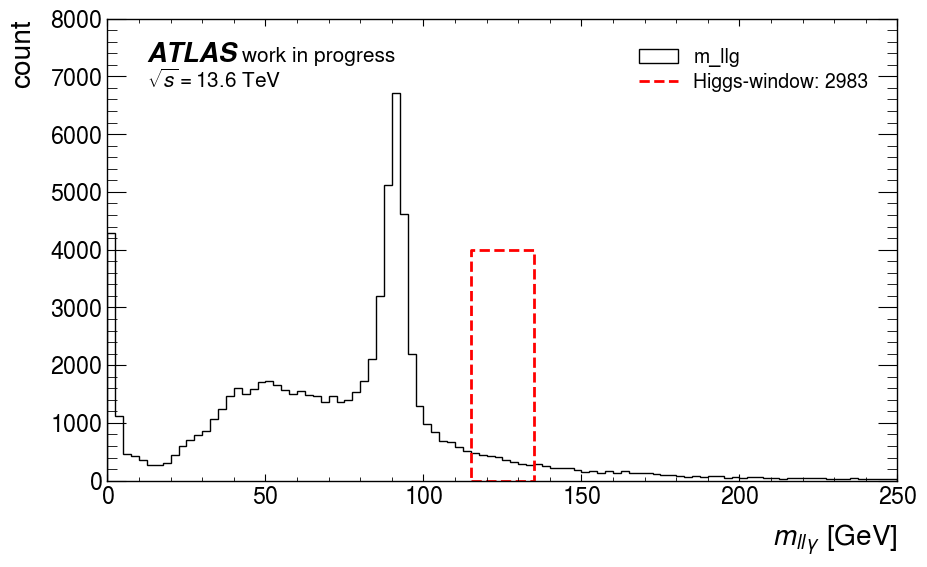

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(true_data['ll_m'], bins=100, range=(0,250),color='black', histtype='step', label='ll_m')
ax.plot([86, 96,96,86,86], [0,0,7000,7000,0], color='red', linestyle='dashed', label=f'Z-window: {np.sum((true_data['ll_m'] > 86) & (true_data['ll_m'] < 96))}')
ax.plot([40, 70, 70, 40, 40], [0,0,4000,4000,0], color='blue', linestyle='dashed', label=f'bck-window: {np.sum((true_data['ll_m'] > 40) & (true_data['ll_m'] < 70) | (true_data['ll_m'] > 105) & (true_data['ll_m'] < 200))}')
ax.plot([105, 200, 200, 105, 105], [0,0,4000,4000,0], color='blue', linestyle='dashed')

ax.legend()
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")
ax.set_xlabel('$m_{ll}$ [GeV]')
ax.set_ylabel('count')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(true_data['llg_m'], bins=100, range=(0,250),color='black', histtype='step', label='m_llg')
ax.plot([115,135,135,115,115], [0,0,4000,4000,0], color='red', linestyle='dashed', label=f'Higgs-window: {np.sum((true_data['llg_m'] > 115) & (true_data['llg_m'] < 135))}')
ax.legend()
ax.set_xlabel('$m_{ll\gamma}$ [GeV]')
ax.set_ylabel('count')
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")

(exptext: Custom Text(0.05, 0.95, 'ATLAS'),
 expsuffix: Custom Text(0.05, 0.955, 'work in progress'),
 supptext: Custom Text(0.05, 0.95, ''),
 expsuffix: Custom Text(0.05, 0.95, '$\\sqrt{s}=13.6$ TeV'))

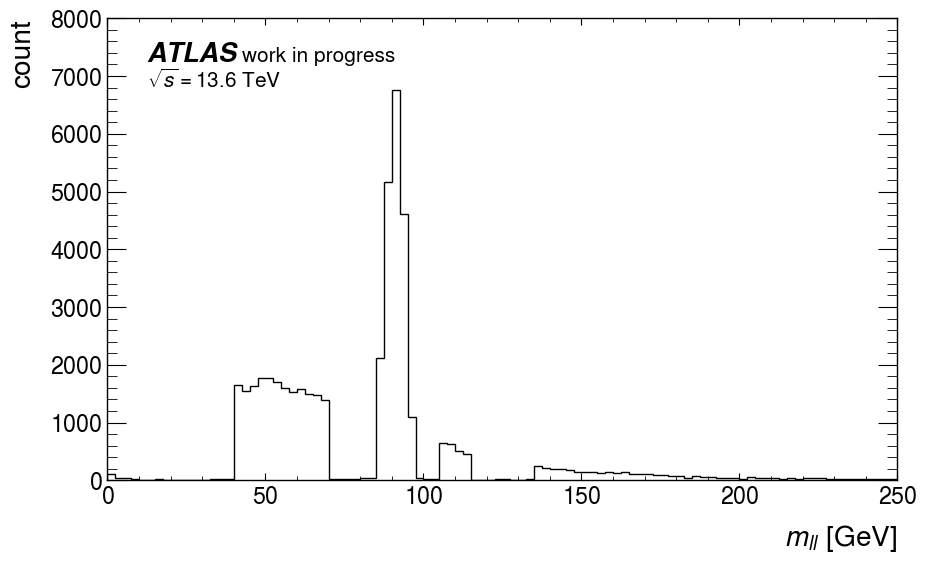

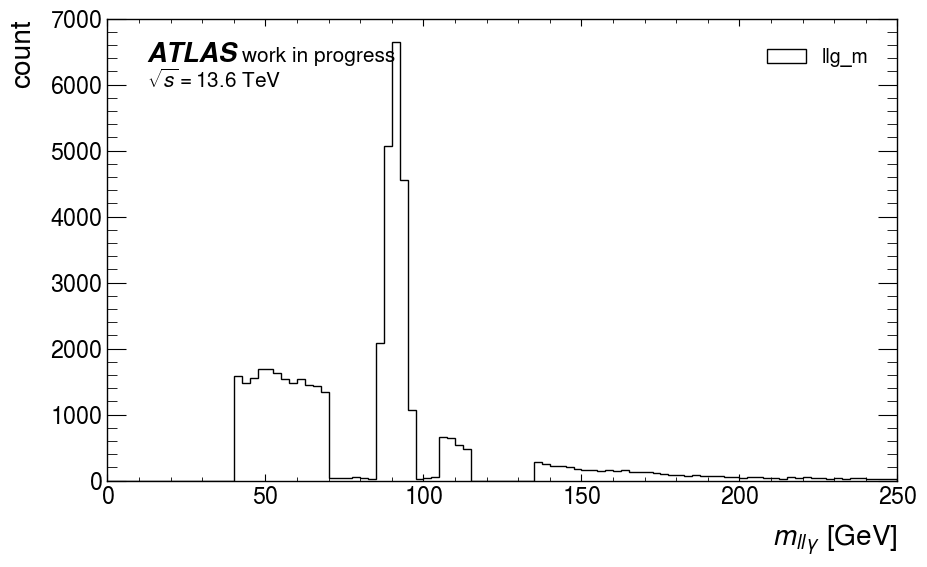

In [8]:
bck_mask = ((true_data['ll_m'] > 40) & (true_data['ll_m'] < 70) | (true_data['ll_m'] > 105) & (true_data['ll_m'] < 200)) & (true_data['llg_m'] < 115) | (true_data['llg_m'] > 135)
z_mask = (true_data['ll_m'] > 86) & (true_data['ll_m'] < 96) & (true_data['llg_m'] < 115) | (true_data['llg_m'] > 135)

label = np.zeros(true_data.shape[0], dtype=bool)
label[z_mask] = 1

true_data['truth_from_Z'] = label

data_reduced = true_data[bck_mask | z_mask]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data_reduced['ll_m'], bins=100, range=(0,250),color='black', histtype='step', label='ll_m')

hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")
ax.set_xlabel('$m_{ll}$ [GeV]')
ax.set_ylabel('count')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data_reduced['llg_m'], bins=100, range=(0,250),color='black', histtype='step', label='llg_m')
ax.legend()
ax.set_xlabel('$m_{ll\gamma}$ [GeV]')
ax.set_ylabel('count')
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")

In [9]:
pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'DZ0']

In [10]:
print(data_reduced.shape)

(45865, 43)


In [11]:
mask = data_reduced['EventInfo.eventNumber'] % 4 != 0
X_train = data_reduced[mask][pred_z_param_list]
y_train = data_reduced[mask]['truth_from_Z']
X_test = data_reduced[~mask]
y_test = data_reduced[~mask]['truth_from_Z']

if os.path.exists(f'trainingondata.pkl'):
    with open(f'trainingondata.pkl', 'rb') as f:
        data_training_model = pickle.load(f)
        id_predictions_small = data_training_model.predict_proba(X_test[pred_z_param_list])
else:
    data_training_model = RapidGBMTuner(metric='auc', trials=1600, refit=True, verbosity=1, visualization=True, seed=414243)
    data_training_model.fit(X_train, y_train)
    data_training_model.fit_optimized(X_train.to_numpy(), y_train.to_numpy())
    with open(f'trainingondata.pkl', 'wb') as f:
        pickle.dump(data_training_model, f)
    id_predictions_small = data_training_model.predict_proba(X_test[pred_z_param_list])
    plt.rcdefaults()
    hep.style.use([hep.style.ATLAS])

In [12]:
print(data_training_model.best_params)
print(data_training_model.best_params['num_iterations'])

{'task': 'train', 'learning_rate': 0.03, 'num_leaves': 177, 'feature_fraction': 0.9676197703664337, 'bagging_fraction': 0.7700776345215647, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'lambda_l1': 3.011561265915604, 'lambda_l2': 1.4585350225275828, 'min_split_gain': 0.0, 'zero_as_missing': False, 'max_bin': 255, 'min_data_in_bin': 3, 'random_state': 42, 'device_type': 'cpu', 'num_classes': 1, 'objective': 'binary', 'metric': 'binary_logloss', 'num_threads': 38, 'min_sum_hessian_in_leaf': 8.053830286500004, 'num_iterations': 128}
128


In [13]:
with open(f'z_tuner_noncross_deltaz.pkl', 'rb') as f:
    MC_training_model = pickle.load(f)

In [14]:
print(MC_training_model.best_params)
print(MC_training_model.best_params['num_iterations'])

{'task': 'train', 'learning_rate': 0.05, 'num_leaves': 29, 'feature_fraction': 0.5068636908503983, 'bagging_fraction': 0.9414689307823287, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'lambda_l1': 7.965686673359615, 'lambda_l2': 4.685534923306145, 'min_split_gain': 0.0, 'zero_as_missing': False, 'max_bin': 255, 'min_data_in_bin': 3, 'random_state': 42, 'device_type': 'cpu', 'num_classes': 1, 'objective': 'binary', 'metric': 'binary_logloss', 'num_threads': 46, 'min_sum_hessian_in_leaf': 8.620736557815617, 'num_iterations': 1108}
1108


In [15]:
for key in MC_training_model.best_params:
    if MC_training_model.best_params[key] != data_training_model.best_params[key]:
        print(f'{key}, MC: {MC_training_model.best_params[key]}, data: {data_training_model.best_params[key]}')

learning_rate, MC: 0.05, data: 0.03
num_leaves, MC: 29, data: 177
feature_fraction, MC: 0.5068636908503983, data: 0.9676197703664337
bagging_fraction, MC: 0.9414689307823287, data: 0.7700776345215647
lambda_l1, MC: 7.965686673359615, data: 3.011561265915604
lambda_l2, MC: 4.685534923306145, data: 1.4585350225275828
num_threads, MC: 46, data: 38
min_sum_hessian_in_leaf, MC: 8.620736557815617, data: 8.053830286500004
num_iterations, MC: 1108, data: 128


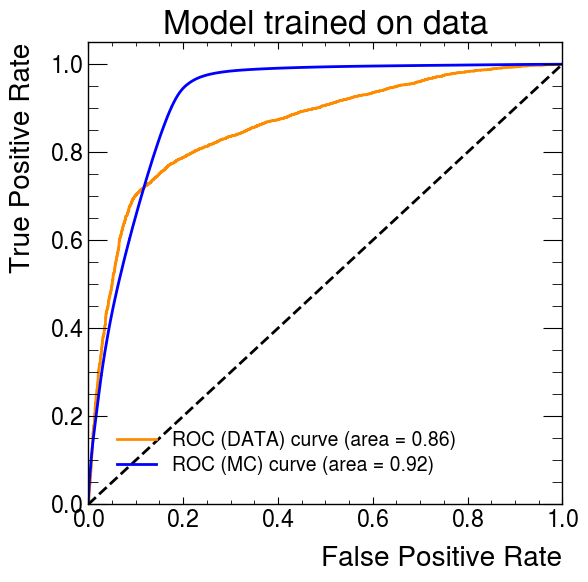

In [16]:
# roc curve

id_pred_MC = data_training_model.predict_proba(MC_data[pred_z_param_list])


fpr, tpr, _ = roc_curve(y_test, id_predictions_small)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label='ROC (DATA) curve (area = %0.2f)' % roc_auc)

fpr, tpr, _ = roc_curve(MC_data['truth_from_Z'], id_pred_MC)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='blue', lw=2, label='ROC (MC) curve (area = %0.2f)' % roc_auc)

ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model trained on data')
ax.legend()

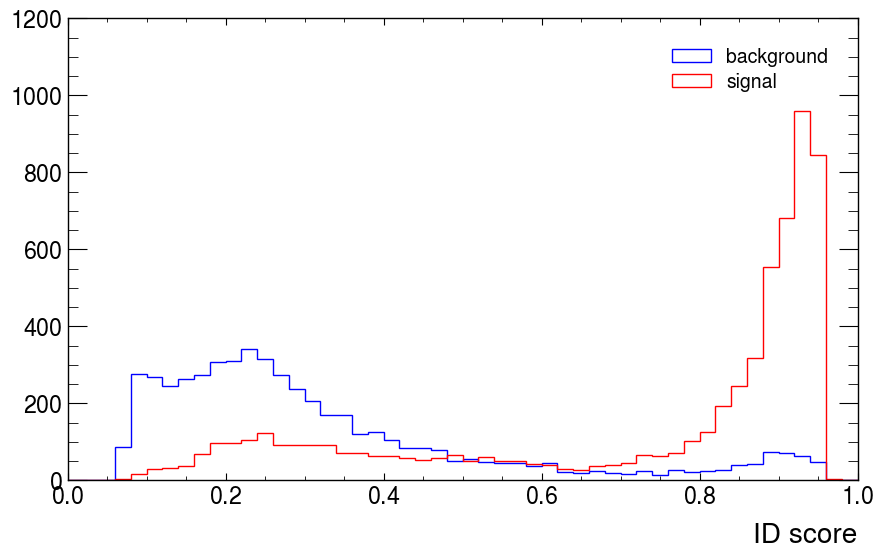

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(id_predictions_small[y_test == 0], bins=50, range=(0,1), color='blue', histtype='step', label='background')
ax.hist(id_predictions_small[y_test == 1], bins=50, range=(0,1), color='red', histtype='step', label='signal')
# ax.set_yscale('log')
ax.set_xlabel('ID score')
ax.legend()

Text(1, 0, 'iso_score')

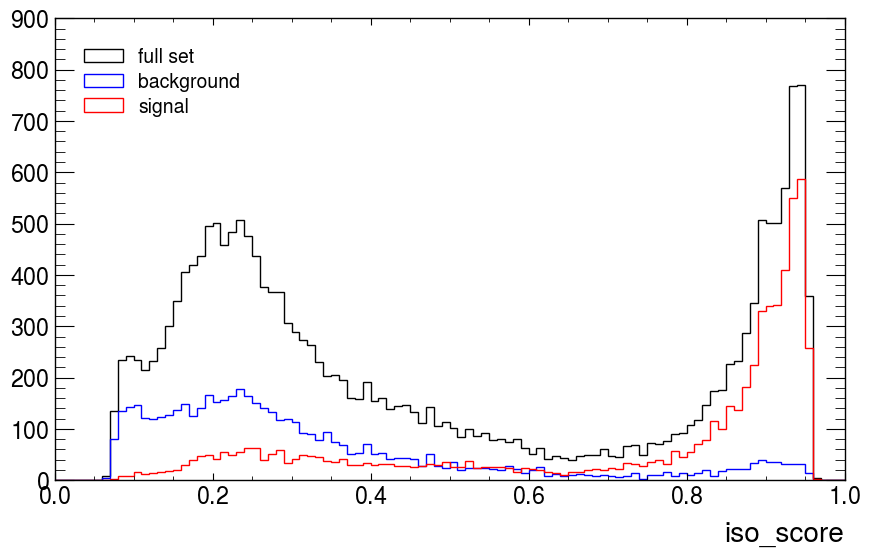

In [18]:
mask = true_data['EventInfo.eventNumber'] % 4 != 0
X_test = true_data[~mask]

id_predictions_full_set = data_training_model.predict_proba(X_test[pred_z_param_list])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(id_predictions_full_set, bins=100, range=(0,1), color='black', histtype='step', label='full set')
ax.hist(id_predictions_small[y_test == 0], bins=100, range=(0,1), color='blue', histtype='step', label='background')
ax.hist(id_predictions_small[y_test == 1], bins=100, range=(0,1), color='red', histtype='step', label='signal')
ax.legend()
ax.set_xlabel('iso_score')

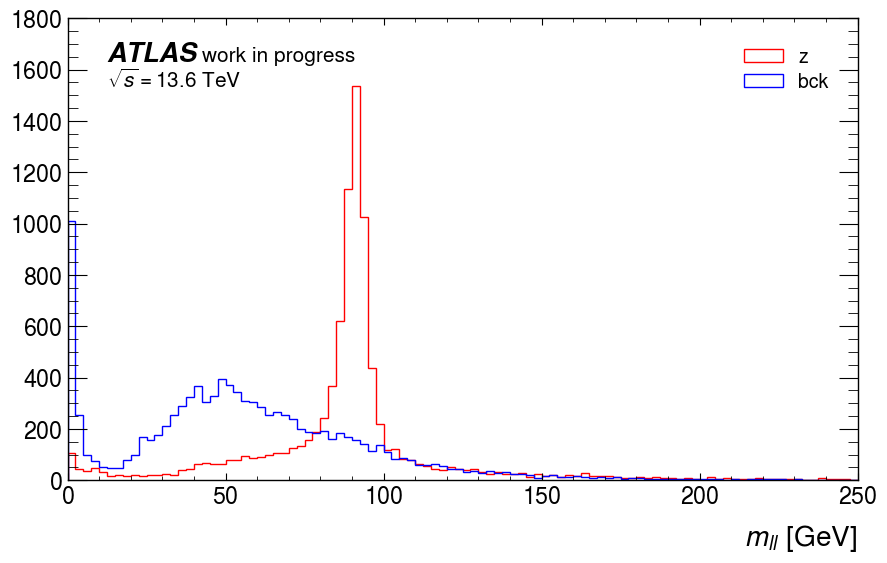

In [19]:
pred = id_predictions_full_set > 0.4

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(X_test['ll_m'][pred], bins=100, range=(0,250), color='red', histtype='step', label='z')
ax.hist(X_test['ll_m'][~pred], bins=100, range=(0,250), color='blue', histtype='step', label='bck')
ax.set_xlabel('$m_{ll}$ [GeV]')
# ax2 = ax.twinx()
# ax2.hist(true_data['ll_m'], bins=100, range=(0,250),color='black', histtype='step', label='ll_m')
hep.atlas.label(data=True, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV")

ax.legend()


In [20]:
small_pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'DZ0']

scale_factor = 1.0

X = pd.concat([MC_data, data_reduced])

print(len(X['isData'])/np.sum(X['isData']))

X_train, X_test, y_train, y_test, is_data_train, is_data_test = train_test_split(
    X[small_pred_z_param_list], X['truth_from_Z'], X['isData'], test_size=0.2, random_state=42
)

192.70395726588902


In [21]:
print(f'data: {data_reduced.shape[0]}, MC: {MC_data.shape[0]}')
print(f'signal data: {data_reduced[data_reduced["truth_from_Z"] == 1].shape[0]}, background data: {data_reduced[data_reduced["truth_from_Z"] == 0].shape[0]}')
print(f'signal MC: {MC_data[MC_data["truth_from_Z"] == 1].shape[0]}, background MC: {MC_data[MC_data["truth_from_Z"] == 0].shape[0]}')

data: 45865, MC: 8792502
signal data: 24777, background data: 21088
signal MC: 4396251, background MC: 4396251


In [22]:
print(data_training_model.best_params)

{'task': 'train', 'learning_rate': 0.03, 'num_leaves': 177, 'feature_fraction': 0.9676197703664337, 'bagging_fraction': 0.7700776345215647, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'lambda_l1': 3.011561265915604, 'lambda_l2': 1.4585350225275828, 'min_split_gain': 0.0, 'zero_as_missing': False, 'max_bin': 255, 'min_data_in_bin': 3, 'random_state': 42, 'device_type': 'cpu', 'num_classes': 1, 'objective': 'binary', 'metric': 'binary_logloss', 'num_threads': 38, 'min_sum_hessian_in_leaf': 8.053830286500004, 'num_iterations': 128}


In [23]:
# # custom loss function:


# def scaled_binary_logloss(y_true, y_pred):
#     """
#     Custom binary log loss with scaling for data.
#     """
#     # Predicted probabilities (sigmoid transformation)
#     y_pred = 1 / (1 + np.exp(-y_pred))
    
#     # Binary log-loss calculation
#     loss = -y_true * np.log(y_pred + 1e-9) - (1 - y_true) * np.log(1 - y_pred + 1e-9)
    
#     # Scale loss for data
#     scaled_loss = np.where(is_data_train, loss * scale_factor, loss)
    
#     # Gradients and Hessians
#     grad = y_pred - y_true  # Gradient of binary log-loss
#     grad = np.where(is_data_train, grad * scale_factor, grad)
    
#     hess = y_pred * (1 - y_pred)  # Hessian of binary log-loss
#     hess = np.where(is_data_train, hess * scale_factor, hess)
    
#     return grad, hess

# train_data = lgb.Dataset(X_train, label=y_train)
# test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# params = {
#     'learning_rate': 0.01, 'num_leaves': 186, 'feature_fraction': 0.6045016560666223, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'lambda_l1': 0.5, 'lambda_l2': 0.0, 'min_split_gain': 0.0, 'zero_as_missing': False, 'max_bin': 255, 'min_data_in_bin': 3, 'random_state': 42, 'device_type': 'cpu', 'num_classes': 1
# }

# # Define parameters
# # params = {
# #     "objective": "binary",
# #     "metric": "binary_logloss",
# #     "boosting_type": "gbdt",
# #     "num_leaves": 31,
# #     "learning_rate": 0.05,
# #     "verbose": -1,
# # }

# # Train the model with custom loss
# gbm = lgb.LGBMClassifier(**params)
# gbm.set_params(objective=scaled_binary_logloss)


# gbm.fit(X_train, y_train, eval_set=[(X_test, y_test)])    


# # Predictions and evaluation
# y_pred = gbm.predict_proba(X_test)
# print("Log Loss:", log_loss(y_test, y_pred))


In [24]:
# print(len(y_test), len(y_pred))
# print(len(y_pred[y_test == 0]), len(y_pred[y_test == 1]))
# print(len(y_pred[(y_test == 1) & (is_data_test == 1)]), len(y_pred[(y_test == 0) & (is_data_test == 1)]))
# print(len(y_pred[(y_test == 1) & (is_data_test == 0)]), len(y_pred[(y_test == 0) & (is_data_test == 0)]))

In [25]:
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.hist(y_pred[(y_test == 0) & (is_data_test == 0)], bins=100, range=(0,1), color='blue', histtype='step', label='MC background')
# ax.hist(y_pred[(y_test == 1) & (is_data_test == 0)], bins=100, range=(0,1), color='red', histtype='step', label='MC signal')
# ax2 = ax.twinx()
# ax2.hist(y_pred[(y_test == 0) & (is_data_test == 1)], bins=100, range=(0,1), color='green', histtype='step', label='data background')
# ax2.hist(y_pred[(y_test == 1) & (is_data_test == 1)], bins=100, range=(0,1), color='orange', histtype='step', label='data signal')
# # ax.hist(y_pred[y_test == 1], bins=100, range=(0,1), color='red', histtype='step', label='signal')
# fig.legend()

# ax.set_xlabel('z_score')

In [26]:
# small_pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'DZ0']

# scale_factor = 1.0

# X = pd.concat([MC_data, data_reduced])

# print(len(X['isData'])/np.sum(X['isData']))

# mask = X['EventInfo.eventNumber'] % 4 != 0
# X_train = X[mask][small_pred_z_param_list]
# y_train = X[mask]['truth_from_Z']
# is_data_train = X[mask]['isData']
# X_test = X[~mask]
# y_test = X[~mask]['truth_from_Z']
# is_data_test = X[~mask]['isData']

In [27]:
# scale_factor = 1.0

# def scaled_binary_crossentropy(y_true, y_pred):
#     """
#     Custom binary cross-entropy loss with scaling for data.
#     """
#     # Predicted probabilities (sigmoid transformation)
#     y_pred = 1 / (1 + np.exp(-y_pred))
    
#     # Gradient and Hessian for binary cross-entropy
#     grad = y_pred - y_true
#     hess = y_pred * (1 - y_pred)
    
#     # Apply scaling for data points
#     if len(y_true) == len(is_data_train):
#         grad = np.where(is_data_train, grad * scale_factor, grad)
#         hess = np.where(is_data_train, hess * scale_factor, hess)
#     elif len(y_true) == len(is_data_test):
#         grad = np.where(is_data_test, grad * scale_factor, grad)
#         hess = np.where(is_data_test, hess * scale_factor, hess)
    
#     return grad, hess

# train_data = lgb.Dataset(X_train, label=y_train)
# test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# params = {
#     'learning_rate': 0.01, 'num_leaves': 186, 'feature_fraction': 0.6045016560666223, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'lambda_l1': 0.5, 'lambda_l2': 0.0, 'min_split_gain': 0.0, 'zero_as_missing': False, 'max_bin': 255, 'min_data_in_bin': 3, 'random_state': 42, 'device_type': 'cpu', 'num_classes': 1
# }

# # Define parameters
# # params = {
# #     "objective": "binary",
# #     "metric": "binary_logloss",
# #     "boosting_type": "gbdt",
# #     "num_leaves": 31,
# #     "learning_rate": 0.05,
# #     "verbose": -1,
# # }

# # Train the model with custom loss
# gbm_bx = lgb.LGBMClassifier(**params)
# gbm_bx.set_params(objective=scaled_binary_crossentropy)


# gbm_bx.fit(X_train, y_train, eval_set=[(X_test[small_pred_z_param_list], y_test)])    


# # Predictions and evaluation
# y_pred = gbm_bx.predict_proba(X_test[small_pred_z_param_list])
# print("binary crossentropy Loss:", scaled_binary_crossentropy(y_test, y_pred))

In [28]:
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.hist(y_pred[(y_test == 0) & (is_data_test == 0)], bins=100, range=(0,1), color='blue', histtype='step', label='MC background')
# ax.hist(y_pred[(y_test == 1) & (is_data_test == 0)], bins=100, range=(0,1), color='red', histtype='step', label='MC signal')
# ax2 = ax.twinx()
# ax2.hist(y_pred[(y_test == 0) & (is_data_test == 1)], bins=100, range=(0,1), color='green', histtype='step', label='data background')
# ax2.hist(y_pred[(y_test == 1) & (is_data_test == 1)], bins=100, range=(0,1), color='orange', histtype='step', label='data signal')
# # ax.hist(y_pred[y_test == 1], bins=100, range=(0,1), color='red', histtype='step', label='signal')
# fig.legend()

# ax.set_xlabel('z_score')

In [29]:
# test = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/user.amoranch.ttbar_PhPy_601589_11Nov_hist/user.amoranch.42039947._000001.hist-output.parquet')
# for col in test.columns:
#     print(col)

In [30]:
print(len(MC_data)/len(data_reduced))

191.70395726588902


In [31]:
pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 'l1_DNN_pel', 'l2_DNN_pel', 'DZ0']


data_df = data_reduced[pred_z_param_list].copy()
mc_df = MC_data[pred_z_param_list].copy()


print(MC_data.columns)


data_df['target'] = data_reduced['truth_from_Z']
mc_df['target'] = MC_data['truth_from_Z']

# mc_df = mc_df.sample(len(data_df), random_state=4222)


# Assume you already have the dataframes `data_df` and `mc_df`
# Add a source column to distinguish MC and Data
data_df['source'] = 'data'
mc_df['source'] = 'mc'

# Combine the datasets
combined_df = pd.concat([data_df, mc_df], ignore_index=True)


weight_scan = np.linspace(0.1, 50, 200)
for i in range(len(weight_scan)):
    # check if the model is already trained
    if os.path.exists(f'plots/roc_curve_{i}.png'):
        continue

    # Assign weights: higher weight for Data, lower weight for MC
    combined_df['weight'] = combined_df['source'].apply(lambda x: weight_scan[i] if x == 'data' else 1)

    # Separate features, target, and weights
    features = [col for col in combined_df.columns if col not in ['target', 'source', 'weight']]
    X = combined_df[features]
    y = combined_df['target']
    weights = combined_df['weight']

    # Split into train and validation sets
    X_train, X_val, y_train, y_val, weights_train, weights_val, source_train, source_val = train_test_split(
        X, y, weights, combined_df['source'], test_size=0.2, random_state=42
    )

    # Create LightGBM datasets
    train_data = lgb.Dataset(X_train, label=y_train, weight=weights_train)
    val_data = lgb.Dataset(X_val, label=y_val, weight=weights_val)

    # Define LightGBM parameters
    params = {
        'objective': 'binary',  # Adjust for your task (e.g., 'regression' or 'multiclass')
        'boosting_type': 'gbdt',
        'metric': 'auc',  # Adjust to your evaluation metric
        'learning_rate': 0.05,
        'num_leaves': 50,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.9,
        'lambda_l1': 1.0,
        'lambda_l2': 1.0,
        'verbose': -1
    }

    # Train the model
    model = lgb.train(
        params,
        train_data,
        num_boost_round=100,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'val'],
        # early_stopping_rounds=50
    )

    # Save the model
    # model.save_model('combined_model.txt')


    # Make predictions
    y_pred = model.predict(X_val)#[:, 1]
    print(f"Weight: {weight_scan[i]}, AUC: {roc_auc_score(y_val, y_pred):.2e}")

    pred_MC = model.predict(X_val[source_val == 'mc'])
    pred_data = model.predict(X_val[source_val == 'data'])
    fpr_MC, tpr_MC, _ = roc_curve(y_val[source_val == 'mc'], pred_MC)
    roc_auc_MC = auc(fpr_MC, tpr_MC)

    fpr_data, tpr_data, _ = roc_curve(y_val[source_val == 'data'], pred_data)
    roc_auc_data = auc(fpr_data, tpr_data)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr_MC, tpr_MC, color='darkorange', lw=2, label='ROC (MC) curve (area = %0.2f)' % roc_auc_MC)
    ax.plot(fpr_data, tpr_data, color='blue', lw=2, label='ROC (data) curve (area = %0.2f)' % roc_auc_data)
    ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Hybrid model, w={weight_scan[i]:.2f}')
    ax.legend()
    fig.savefig(f'plots/roc_curve_{i}.png')
    plt.close(fig)

Index(['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
       'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000',
       'l1_ptvarcone30_pt500', 'l1_topoetcone20',
       'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20',
       'l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
       'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000',
       'l2_ptvarcone30_pt500', 'l2_topoetcone20',
       'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20',
       'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0',
       'EventInfo.actualIntPerXing', 'EventInfo.averageIntPerXing',
       'EventInfo.mu', 'EventInfo.eventNumber', 'truth_from_Z',
       'EventInfo.cutflow', 'EventInfo.cutflow_new', 'll_m', 'l1_truthType',
       'l2_truthType', 'isData', 'DZ0', 'l1_iso_score', 'l2_iso_score'],
      dtype='object')


In [32]:
# Get the list of image files
import cv2
img_files = []
for i in range(len(weight_scan)):
    img_files.append(f'plots/roc_curve_{i}.png')
# img_files = sorted(glob.glob('plots/roc_curve_*.png'))

# print(img_files)

# Define the codec and create a VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mp4 files
fps = 10  # Frames per second
frame_size = (600, 600)  # Frame size (width, height)

# Create a VideoWriter object
out = cv2.VideoWriter('output_video_roc.mp4', fourcc, fps, frame_size)

for img_file in img_files:
    img = cv2.imread(img_file)
    img = cv2.resize(img, frame_size)  # Resize image to match frame size
    out.write(img)

# Release the VideoWriter object
out.release()

In [33]:
pred_MC = model.predict(X_val[source_val == 'mc'])
pred_data = model.predict(X_val[source_val == 'data'])

NameError: name 'model' is not defined

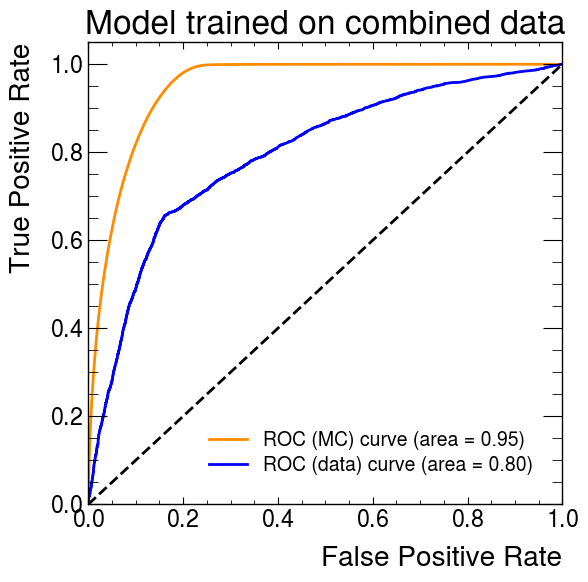

In [ ]:
fpr_MC, tpr_MC, _ = roc_curve(y_val[source_val == 'mc'], pred_MC)
roc_auc_MC = auc(fpr_MC, tpr_MC)

fpr_data, tpr_data, _ = roc_curve(y_val[source_val == 'data'], pred_data)
roc_auc_data = auc(fpr_data, tpr_data)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_MC, tpr_MC, color='darkorange', lw=2, label='ROC (MC) curve (area = %0.2f)' % roc_auc_MC)
ax.plot(fpr_data, tpr_data, color='blue', lw=2, label='ROC (data) curve (area = %0.2f)' % roc_auc_data)
ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model trained on combined data')
ax.legend()